USE CASE

User Input -> LLM(answers in english) -> LLM(translated english to hindi response) -> Hindi Response is returned as an output.

Importing all necessary libraries

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv

C:\Users\khana\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

Here is only one state which is shared among parentgraph and subgraph

In [3]:
class SharedState(TypedDict):

    user_input: str
    english_response: str
    hindi_response:str

In [4]:
llm = ChatGroq(model = "LLaMA-3.1-8B-Instant")

Subgraph

In [5]:
def translate_to_hindi(state: SharedState):

    prompt = f"Translate the following english text to hindi in proper, clean and simple manner\n {state['english_response']}"

    translated_response = llm.invoke(prompt).content

    return {"hindi_response": translated_response}

In [6]:
s_graph = StateGraph(SharedState)

s_graph.add_node("translate_hindi", translate_to_hindi)

s_graph.add_edge(START, "translate_hindi")
s_graph.add_edge("translate_hindi", END)

subgraph = s_graph.compile()

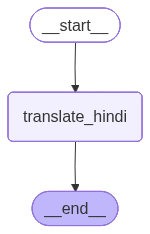

In [7]:
subgraph

ParentGrpah

In [8]:
def generate_reponse_in_eng(state: SharedState):

    prompt = f"Answer the following question or query in clean, simple and easy to understandable terms\n{state['user_input']}"
    eng_reponse = llm.invoke(prompt).content

    return {"english_response": eng_reponse}

In [ ]:
p_graph = StateGraph(SharedState)

p_graph.add_node("generate_reponse_in_eng", generate_reponse_in_eng)
p_graph.add_node("translate_to_hindi", subgraph) # This integrates the subgraph into a parentgraph via this subgraph variable which compiles the subgraph in above cell.

p_graph.add_edge(START, "generate_reponse_in_eng")
p_graph.add_edge("generate_reponse_in_eng", "translate_to_hindi")
p_graph.add_edge("translate_to_hindi", END)

parentgraph = p_graph.compile()

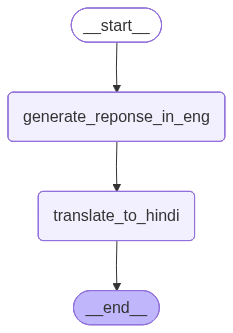

In [10]:
parentgraph

Test

In [12]:
parentgraph.invoke({'user_input': 'What is Agentic AI'})

{'user_input': 'What is Agentic AI',
 'english_response': '**Agentic AI** is a type of artificial intelligence (AI) that behaves in a more autonomous and goal-oriented way, similar to a human agent.\n\nAn **agent** is an entity that can make decisions, take actions, and interact with its environment to achieve its goals. In the context of AI, an agentic AI system is designed to:\n\n1. **Perceive**: Understand its environment and gather information.\n2. **Reason**: Make decisions based on its perception and goals.\n3. **Act**: Take actions to achieve its goals.\n4. **Learn**: Adapt and improve its behavior over time.\n\nAgentic AI systems are often characterized by their ability to:\n\n* Take initiative and act independently\n* Make decisions without explicit instructions\n* Adapt to changing circumstances\n* Exhibit creativity and problem-solving skills\n\nExamples of agentic AI include:\n\n* Personal assistants like Siri or Alexa, which can understand and respond to user requests\n* A